# 03 — Attention from Scratch (SDPA, Causal Mask, Multi-Head, GQA)

Welcome back! In notebook 02 we proved that even dense learned embeddings are
**order-blind**: the model's prediction for `"the king is dead"` is identical to
its prediction for `"dead is king the"`. The sequence order — which word comes first,
which word comes last — is invisible to mean-pooling.

This notebook introduces **attention**, the mechanism that fixes the order problem.
Attention allows each token to *look at* other tokens in the sequence and decide
which ones are most relevant. Order finally matters because each token knows
*where it sits* relative to every other token.

## What you will build

We will construct four things from scratch, each one building on the last:

1. **Scaled dot-product attention (SDPA)** — the core mathematical operation.
2. **Causal mask** — ensures a token can only attend to *past* tokens (no peeking ahead).
3. **Multi-head attention (MHA)** — runs several attention computations in parallel,
   each looking for different kinds of relationships.
4. **Grouped-query attention (GQA)** — a memory-efficient variant used in modern large
   models (Llama 3, Mistral, etc.) where keys and values are shared across groups of heads.

These are **pedagogical** ("teaching") versions written for clarity. The canonical
production implementation lives in `model.py` (a later task).

## A note on working directories

Jupyter runs a notebook from the folder the notebook lives in (`notebooks/`), not from
the project root. That means paths like `data/` and `assets/` would silently resolve
to `notebooks/data/` and `notebooks/assets/` — the wrong place. The cell below walks
up the directory tree until it finds the project root (identified by `requirements.txt`)
and changes the kernel's working directory there. After this cell runs, every path in
the notebook is relative to the project root, no matter how you launched Jupyter.

In [1]:
import os
# Walk up to the repo root so relative paths (data/, assets/, checkpoints/) resolve
# no matter which directory the notebook kernel was launched from.
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():          # reached filesystem root; stop
        break
    os.chdir(parent)
print("Working directory:", os.getcwd())

Working directory: /Users/carlosbarbosa/Documents/GitHub/train-llm


## Imports and reproducibility

We import `math` for the square-root used in scaling, `torch` and `torch.nn` for
tensors and neural-network modules, and `matplotlib` for the attention visualization.

`torch.manual_seed(1337)` fixes the random number generator so every run of this
notebook (as a script or rendered notebook) produces the same numbers. This makes
experiments reproducible — you can share the notebook and know the other person
sees the same outputs.

`device` selects a GPU if one is available (MPS on Apple Silicon, CUDA on Nvidia).
On a CPU-only machine it gracefully falls back to `cpu`.

In [2]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)
# Auto-detect the best compute engine: CUDA (NVIDIA) -> MPS (Apple Silicon) -> CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)
# Note: these small teaching cells run on CPU for clarity; the full model (later notebooks) uses the detected GPU/MPS device.

device: mps


## The big idea: what is attention?

Before writing a single line of code, let's build up the intuition.

### The problem attention solves

Imagine reading the sentence: `"The animal didn't cross the street because it was too tired."`.
When you read the word `"it"`, your brain instantly looks back and connects it to
`"animal"`, not to `"street"`. You do this by deciding which earlier words are
*relevant* to understanding `"it"`. That relevance-weighted lookback is exactly what
attention computes.

In a sequence model, at each position `t` we want to ask: *"Which other positions
should I look at, and how much should I weight each one's information?"* Attention
answers this question with a learned, data-dependent weighting.

### Queries, keys, and values

Attention is built around three learned projections of each token's embedding:

- **Query (Q)**: "What am I looking for?" — each token projects itself into a query
  vector that represents the kind of information it wants to gather.
- **Key (K)**: "What do I offer?" — each token projects itself into a key vector
  that represents the kind of information it contains.
- **Value (V)**: "What do I share if selected?" — each token projects itself into a
  value vector that contains the actual information it will contribute.

The intuition: Q and K interact (via a dot product) to decide *how much attention* to
pay. V is then weighted by those attention amounts to produce the output.

### Step-by-step walkthrough

Given Q, K, V all of shape `(batch_size, sequence_length, head_dim)`:

1. **Compute scores**: `scores = Q @ K^T` — for every pair of positions `(i, j)`,
   measure how well query-at-`i` matches key-at-`j`. The result has shape `(B, T, T)`.

2. **Scale**: divide scores by `√head_dim`. Without this, the dot products grow large
   as `head_dim` increases, pushing softmax into regions where gradients vanish.
   Think of it as keeping the numbers in a reasonable range before softmax.

3. **Mask** (for causal / autoregressive models): set scores for future positions to
   `-∞`. After softmax, `-∞` becomes `0`, so future positions receive zero attention.

4. **Softmax**: convert scores to probabilities along the `T` dimension. Each row now
   sums to 1 — these are the **attention weights**.

5. **Weighted sum**: multiply the weights by V. Each position's output is a weighted
   mixture of all other positions' value vectors, with the weights determined by
   query-key similarity.

## Part 1 — Scaled dot-product attention

Let's implement the five steps above in a single function: `scaled_dot_product_attention`.

### The causal mask

Language models generate text left-to-right: position `t` should only be allowed to
look at positions `0, 1, ..., t` (itself and the past). It must **never** look ahead
to positions `t+1, t+2, ...` — that would be cheating during training because the
model would see the answer before predicting it.

We enforce this with a **causal mask**: a lower-triangular matrix of `True` values.
`torch.tril(torch.ones(T, T))` creates:
```
[[1, 0, 0, 0, 0],
 [1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0],
 [1, 1, 1, 1, 1]]
```
Every `0` in this mask marks a future position. We fill those positions in the score
matrix with `-inf`. After softmax, `-inf → exp(-inf) = 0`, so no information flows
from future positions.

### Reading the code

- `q @ k.transpose(-2, -1)` — batch matrix multiply; swaps the last two dims of `k`
  so the inner dimensions align: `(B, T, d) @ (B, d, T) = (B, T, T)`.
- `/ math.sqrt(d)` — the scaling factor; `d = head_dim`.
- `masked_fill(~mask, float("-inf"))` — fill positions where `~mask` is `True` (i.e.
  upper triangle) with `-inf`.
- `torch.softmax(..., dim=-1)` — normalize along the last dimension (each row sums to 1).
- `weights @ v` — weighted sum of value vectors; shape `(B, T, head_dim)`.

In [3]:
def scaled_dot_product_attention(q, k, v, causal=True):
    """
    Scaled dot-product attention (single head).

    Args:
        q: query tensor,  shape (B, T, head_dim)
        k: key tensor,    shape (B, T, head_dim)
        v: value tensor,  shape (B, T, head_dim)
        causal: if True, apply a lower-triangular mask so each position
                can only attend to positions at or before itself.

    Returns:
        out:     (B, T, head_dim) — the attended output
        weights: (B, T, T)        — the attention weight matrix
    """
    d = q.size(-1)                                              # head_dim
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d)          # (B, T, T)
    if causal:
        T = scores.size(-1)
        mask = torch.tril(torch.ones(T, T, device=scores.device)).bool()
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ v, weights

### Assert: the causal mask works

With `causal=True`, the attention weight matrix must be **lower-triangular**: no weight
can appear *above* the diagonal, because that would mean a current token is attending
to a future token.

`w.triu(1)` extracts the strict upper triangle (diagonal=1 means exclude the main
diagonal). Every entry there must be zero after the causal mask is applied. We check
this with `torch.allclose(..., atol=1e-6)` — a numerical equality check with a small
tolerance for floating-point rounding.

Concretely:
- `B=1` batch, `T=5` sequence length, `d=8` head dimension.
- Random Q, K, V are generated.
- After attention with `causal=True`, the upper triangle of `w` must be all zeros.

In [4]:
B, T, d = 1, 5, 8
q = torch.randn(B, T, d)
k = torch.randn(B, T, d)
v = torch.randn(B, T, d)
out, w = scaled_dot_product_attention(q, k, v, causal=True)
assert torch.allclose(w.triu(1), torch.zeros_like(w), atol=1e-6), \
    "causal attention weights must be zero above the diagonal"
print("SDPA causal assert passed — upper triangle is all zeros.")
print("output shape:", tuple(out.shape))   # (1, 5, 8)

SDPA causal assert passed — upper triangle is all zeros.
output shape: (1, 5, 8)


## Part 2 — Multi-head attention

### Why multiple heads?

A single attention head computes one set of Q, K, V projections and learns one type
of relationship between tokens. But language has many kinds of relationships at once:

- One head might learn syntactic dependencies (subject ↔ verb agreement).
- Another head might learn semantic proximity (nouns ↔ their modifiers).
- Another might learn long-range coreference (pronoun ↔ its antecedent).

**Multi-head attention** runs `n_head` independent attention computations in parallel,
each with its own learnable Q, K, V projection matrices. The outputs of all heads are
then concatenated and projected back to the original embedding dimension.

### How the dimensions work

- Input: `(B, T, n_embd)` — batch, sequence, embedding dimension.
- Each head works on a sub-space of size `head_dim = n_embd // n_head`.
- The Q, K, V projections (linear layers with no bias) map
  `n_embd → n_head * head_dim = n_embd` — same total size, split across heads.
- After SDPA, each head produces `(B, T, head_dim)`.
- All heads concatenated: `(B, T, n_head * head_dim) = (B, T, n_embd)`.
- Output projection: `(B, T, n_embd) → (B, T, n_embd)` — mixes the heads together.

### Reading the code

- `self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)` — one matrix computes Q, K,
  and V simultaneously; we split it into three equal chunks with `.chunk(3, dim=-1)`.
- `.view(B, T, self.n_head, self.head_dim).transpose(1, 2)` — reshape so we get
  `(B, n_head, T, head_dim)`, then call `scaled_dot_product_attention` per head.
  (Here we iterate over heads for pedagogical clarity; production code uses batched ops.)
- After concatenating all head outputs: `.transpose(1, 2).contiguous().view(B, T, n_embd)`
  — reassemble back to `(B, T, n_embd)`.
- `self.out_proj = nn.Linear(n_embd, n_embd, bias=False)` — the final mixing projection.

In [5]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention module (pedagogical version).

    Args:
        n_embd:  total embedding dimension.
        n_head:  number of attention heads. Must divide n_embd evenly.
        causal:  whether to apply the causal (lower-triangular) mask.
    """
    def __init__(self, n_embd: int, n_head: int, causal: bool = True):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.causal = causal

        # Project input to queries, keys, and values — all at once.
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        # Mix all head outputs back to n_embd.
        self.out_proj = nn.Linear(n_embd, n_embd, bias=False)

    def forward(self, x):
        """
        Args:
            x: (B, T, n_embd)
        Returns:
            out: (B, T, n_embd)
        """
        B, T, n_embd = x.shape

        # Compute Q, K, V in one matrix multiply, then split.
        q, k, v = self.qkv(x).chunk(3, dim=-1)   # each: (B, T, n_embd)

        # Reshape so each head gets its own slice: (B, n_head, T, head_dim)
        def split_heads(t):
            return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Run attention for each head independently.
        head_outs = []
        for h in range(self.n_head):
            head_out, _ = scaled_dot_product_attention(
                q[:, h], k[:, h], v[:, h], causal=self.causal
            )
            head_outs.append(head_out)  # each: (B, T, head_dim)

        # Concatenate along the feature dimension: (B, T, n_embd)
        combined = torch.cat(head_outs, dim=-1)

        return self.out_proj(combined)

### Assert: MHA output shape

No matter how many heads we use, the output must always have the same shape as the
input — `(B, T, n_embd)`. This is a critical invariant: the residual stream in a
transformer adds the attention output back to the original embedding, so the shapes
must match.

In [6]:
B, T, n_embd, n_head = 2, 10, 64, 4
mha = MultiHeadAttention(n_embd=n_embd, n_head=n_head)
x = torch.randn(B, T, n_embd)
out = mha(x)
assert out.shape == (B, T, n_embd), f"expected {(B, T, n_embd)}, got {tuple(out.shape)}"
print("MHA output shape assert passed:", tuple(out.shape))

MHA output shape assert passed: (2, 10, 64)


## Part 3 — Grouped-query attention (GQA)

### The KV-cache problem in large models

During inference (text generation), a transformer generates one token at a time. To
avoid recomputing keys and values for all previous tokens at each step, models cache
them in a **KV-cache**. In a large model with many layers and many attention heads,
this cache can consume tens of gigabytes of memory.

**Grouped-query attention (GQA)** is a technique introduced to reduce this cost.
Instead of giving every query head its own key and value heads (standard MHA), GQA
uses **fewer KV heads** that are **shared across groups** of query heads.

### How it works

- Standard MHA: `n_head` Q heads, `n_head` K heads, `n_head` V heads.
- GQA: `n_head` Q heads, but only `n_kv_head` K heads and `n_kv_head` V heads,
  where `n_kv_head ≤ n_head` and `n_kv_head` divides `n_head` evenly.
- The number of Q heads per KV head is `n_rep = n_head // n_kv_head`.
- Each KV head is **repeated** `n_rep` times so it can be broadcast against all the
  Q heads in its group. In PyTorch we use `repeat_interleave` for this.

### Special cases

- `n_kv_head == n_head` (i.e., `n_rep == 1`): identical to standard MHA. No K/V
  are repeated — each query head has its own key and value.
- `n_kv_head == 1`: this is **multi-query attention (MQA)** — all query heads share
  a *single* set of keys and values. Maximum memory savings, slight quality cost.

### Parameter savings

Standard MHA Q/K/V projections: `3 × n_embd × n_embd` parameters.
GQA Q/K/V projections: `n_embd × n_embd` (Q) + `2 × n_embd × (n_kv_head/n_head × n_embd)`.
For `n_kv_head = n_head // 4`, the K and V projections shrink by 4×.

### Reading the code

- `self.q_proj` projects to the full `n_embd` (all query heads).
- `self.kv_proj` projects to `2 × kv_embd` where `kv_embd = n_kv_head × head_dim`
  (only the KV heads, which is a smaller dimension).
- `repeat_interleave(n_rep, dim=1)` — along the head dimension (dim 1), repeat each
  KV head `n_rep` times. After this, K and V have shape `(B, n_head, T, head_dim)`,
  matching Q exactly.

In [7]:
class GroupedQueryAttention(nn.Module):
    """
    Grouped-query attention (GQA) module (pedagogical version).

    Args:
        n_embd:    total embedding dimension.
        n_head:    number of query heads. Must divide n_embd evenly.
        n_kv_head: number of key/value heads. Must divide n_head evenly.
                   n_kv_head == n_head → standard MHA (n_rep == 1).
                   n_kv_head == 1      → multi-query attention (MQA).
        causal:    whether to apply the causal mask.
    """
    def __init__(self, n_embd: int, n_head: int, n_kv_head: int, causal: bool = True):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        assert n_head % n_kv_head == 0, "n_head must be divisible by n_kv_head"

        self.n_head = n_head
        self.n_kv_head = n_kv_head
        self.n_rep = n_head // n_kv_head   # how many Q-heads share each KV-head
        self.head_dim = n_embd // n_head
        self.causal = causal

        kv_dim = n_kv_head * self.head_dim  # smaller than n_embd when n_kv_head < n_head

        # Q uses all n_head heads; K and V use only n_kv_head heads.
        self.q_proj  = nn.Linear(n_embd, n_embd, bias=False)
        self.kv_proj = nn.Linear(n_embd, 2 * kv_dim, bias=False)
        self.out_proj = nn.Linear(n_embd, n_embd, bias=False)

    def forward(self, x):
        """
        Args:
            x: (B, T, n_embd)
        Returns:
            out: (B, T, n_embd)
        """
        B, T, _ = x.shape

        # Query projection — full n_head heads.
        q = self.q_proj(x)                                          # (B, T, n_embd)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, n_head, T, head_dim)

        # Key and value projections — only n_kv_head heads.
        k, v = self.kv_proj(x).chunk(2, dim=-1)                    # each: (B, T, kv_dim)
        k = k.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)  # (B, n_kv_head, T, head_dim)
        v = v.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)  # (B, n_kv_head, T, head_dim)

        # Repeat each KV head n_rep times to match the number of Q heads.
        # After repeat_interleave: (B, n_head, T, head_dim)
        k = k.repeat_interleave(self.n_rep, dim=1)
        v = v.repeat_interleave(self.n_rep, dim=1)

        # Run attention for each head independently (same as MHA).
        head_outs = []
        for h in range(self.n_head):
            head_out, _ = scaled_dot_product_attention(
                q[:, h], k[:, h], v[:, h], causal=self.causal
            )
            head_outs.append(head_out)  # (B, T, head_dim)

        combined = torch.cat(head_outs, dim=-1)   # (B, T, n_embd)
        return self.out_proj(combined)

### Asserts: GQA output shape and the n_rep == 1 equivalence

We check two things:

1. **Shape invariant**: just like MHA, GQA must return `(B, T, n_embd)` regardless of
   how many KV heads are used.

2. **n_rep == 1 check**: when `n_kv_head == n_head`, the number of repetitions is 1
   (no repeating), so GQA is equivalent to standard MHA. This is the degenerate case
   that tells us GQA is a strict generalization of MHA — we can dial `n_kv_head` from
   1 (MQA, maximum sharing) to `n_head` (MHA, no sharing).

In [8]:
B, T, n_embd, n_head, n_kv_head = 2, 10, 64, 4, 2
gqa = GroupedQueryAttention(n_embd=n_embd, n_head=n_head, n_kv_head=n_kv_head)
x = torch.randn(B, T, n_embd)
out = gqa(x)

# Assert 1: output shape is always (B, T, n_embd).
assert out.shape == (B, T, n_embd), f"expected {(B, T, n_embd)}, got {tuple(out.shape)}"
print("GQA output shape assert passed:", tuple(out.shape))

# Assert 2: when n_kv_head == n_head, n_rep == 1 (no key/value repetition).
gqa_mha_equiv = GroupedQueryAttention(n_embd=n_embd, n_head=n_head, n_kv_head=n_head)
assert gqa_mha_equiv.n_rep == 1, \
    f"with n_kv_head == n_head, n_rep should be 1, got {gqa_mha_equiv.n_rep}"
print(f"GQA n_rep==1 assert passed: n_kv_head={n_head} (== n_head) → n_rep={gqa_mha_equiv.n_rep}")

GQA output shape assert passed: (2, 10, 64)
GQA n_rep==1 assert passed: n_kv_head=4 (== n_head) → n_rep=1


## Part 4 — Visualizing attention weights

Now let's make the math tangible. We will:
1. Take a short character sequence from Shakespeare.
2. Run it through a single attention head.
3. Plot the attention weight matrix as a heatmap.

### What the heatmap shows

The attention weight matrix has shape `(T, T)`. Row `i` tells us: *"When producing
the output at position `i`, how much did we attend to each other position `j`?"*
The value at `[i, j]` is the attention weight from position `i` to position `j`.

Because of the causal mask:
- The **lower triangle** (including the diagonal) has non-zero weights — these are the
  past and current positions a token is allowed to look at.
- The **upper triangle** is all zeros — these are future positions that are masked out.

The pattern you'll see is a triangular heat pattern: earlier rows have fewer options
to attend to (only positions 0 through i), while later rows spread attention over
more positions.

### Setup

We reuse the character-level tokenizer from notebook 02: map each unique character in
Shakespeare to an integer, then embed those integers with a small `nn.Embedding` table.
This gives us a proper embedding tensor to feed into our attention function.

In [9]:
os.makedirs("assets", exist_ok=True)

# ---- tiny character-level data setup (self-contained) ----
DATA_PATH = "data/shakespeare.txt"
# Falls back to a short inline sample if the dataset hasn't been downloaded yet (run notebook 01 to fetch it).
if os.path.exists(DATA_PATH):
    raw = open(DATA_PATH, encoding="utf-8").read()
else:
    raw = "To be, or not to be, that is the question."

chars = sorted(set(raw))
cstoi = {c: i for i, c in enumerate(chars)}
char_vocab_size = len(chars)

# Pick a short sequence to visualize.
sample_text = "To be, or not to be"
sample_ids = torch.tensor([cstoi[c] for c in sample_text], dtype=torch.long)  # (T,)
T_vis = len(sample_ids)
print(f"Sequence: {repr(sample_text)}  ({T_vis} chars)")

# Embed the character ids with a small learned embedding.
VIS_DIM = 32   # embedding / head dimension for visualization
emb = nn.Embedding(char_vocab_size, VIS_DIM)
x_vis = emb(sample_ids).unsqueeze(0)   # (1, T_vis, VIS_DIM)

Sequence: 'To be, or not to be'  (19 chars)


### Run attention and plot

We use simple random linear projections (no training) just to produce a weight matrix.
The goal is to see the *structure* enforced by the causal mask — the training step
would tune the projections so that weights reflect linguistic relevance.

`plt.imshow` renders the weight matrix as a grid of colored squares. Brighter colors
indicate higher attention weight. The triangular pattern proves the causal constraint
is working: the top-right corner is always dark (zero weights for future positions).

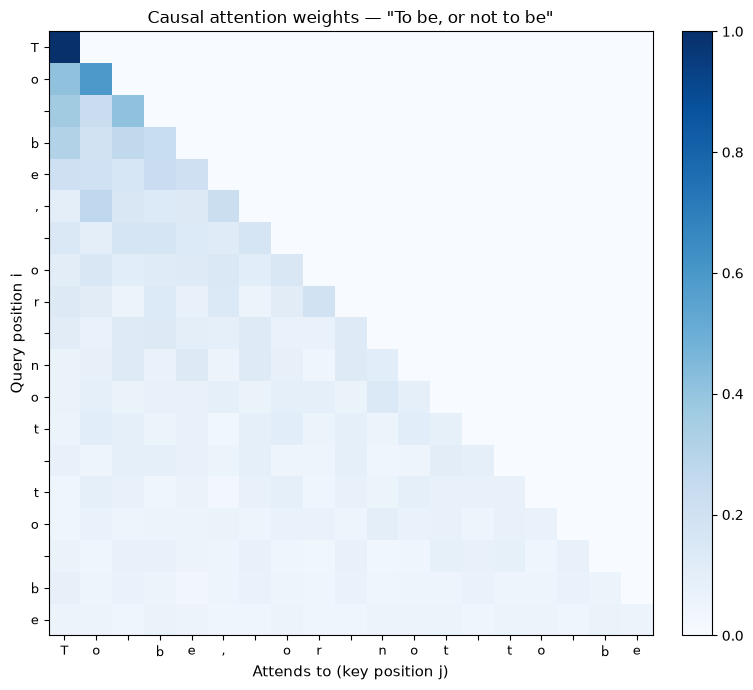

Saved: assets/03_attention_weights.png


In [10]:
torch.manual_seed(1337)   # reset seed so the plot is deterministic

# Simple Q, K, V projections for one head.
W_q = nn.Linear(VIS_DIM, VIS_DIM, bias=False)
W_k = nn.Linear(VIS_DIM, VIS_DIM, bias=False)
W_v = nn.Linear(VIS_DIM, VIS_DIM, bias=False)

with torch.no_grad():
    q_vis = W_q(x_vis)   # (1, T_vis, VIS_DIM)
    k_vis = W_k(x_vis)
    v_vis = W_v(x_vis)
    _, weights_vis = scaled_dot_product_attention(q_vis, k_vis, v_vis, causal=True)

# weights_vis shape: (1, T_vis, T_vis) — squeeze the batch dim for plotting.
w_plot = weights_vis.squeeze(0).detach().numpy()   # (T_vis, T_vis)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(w_plot, cmap="Blues", vmin=0.0, vmax=w_plot.max())
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

chars_vis = list(sample_text)
ax.set_xticks(range(T_vis)); ax.set_xticklabels(chars_vis, fontsize=9)
ax.set_yticks(range(T_vis)); ax.set_yticklabels(chars_vis, fontsize=9)
ax.set_xlabel("Attends to (key position j)", fontsize=11)
ax.set_ylabel("Query position i", fontsize=11)
ax.set_title(f'Causal attention weights — "{sample_text}"', fontsize=12)
plt.tight_layout()
plt.savefig("assets/03_attention_weights.png", dpi=120)
plt.show()
print("Saved: assets/03_attention_weights.png")

### What we see in the plot

- The **lower-left triangle** (including diagonal) is non-zero: each character can
  attend to all characters that came before it (and itself).
- The **upper-right triangle** is completely dark (zero): no character can peek at
  future characters. This is the causal mask in action.
- The first row has only one non-zero entry (the character can only attend to itself).
- The last row has non-zero entries across the whole lower triangle — the final
  character has access to the entire sequence so far.
- The exact brightness pattern depends on the random Q, K, V weights; after training,
  these weights would encode linguistically meaningful patterns (e.g. matching subjects
  to verbs, pronouns to their referents).

## Summary

In this notebook we built attention from scratch in four steps:

| Component | Key idea |
|---|---|
| `scaled_dot_product_attention` | Q·K^T / √d → softmax → ·V |
| Causal mask | Lower-triangular `True` matrix; future positions → `-inf` → `0` weight |
| `MultiHeadAttention` | Split embedding into `n_head` independent attention subspaces |
| `GroupedQueryAttention` | Reduce KV heads via `repeat_interleave`; saves memory/KV-cache |

These pedagogical versions expose every operation clearly. The production implementation
(`model.py`, Task 4) will fuse and optimize these operations — but the math is identical.

**Next:** notebook 04 will assemble these pieces into a full transformer block (attention
+ feed-forward + layer norms + residual connections).